# Denoising images

# Modelling

> *All models are wrong, but some are useful.*
> 
> \- George Box

## What is an image

* Mathematicians like to think of images as vector-valued functions
* Computer scientists like to think of images as multi-dimensional arrays
* We can even think of images as graphs

For today, we focus on grey-scale images represented as 2D arrays $F \in \mathbb{R}^{n\times n}$ or 1D arrays $\mathbf{f}\in\mathbb{R}^{n^2}$.

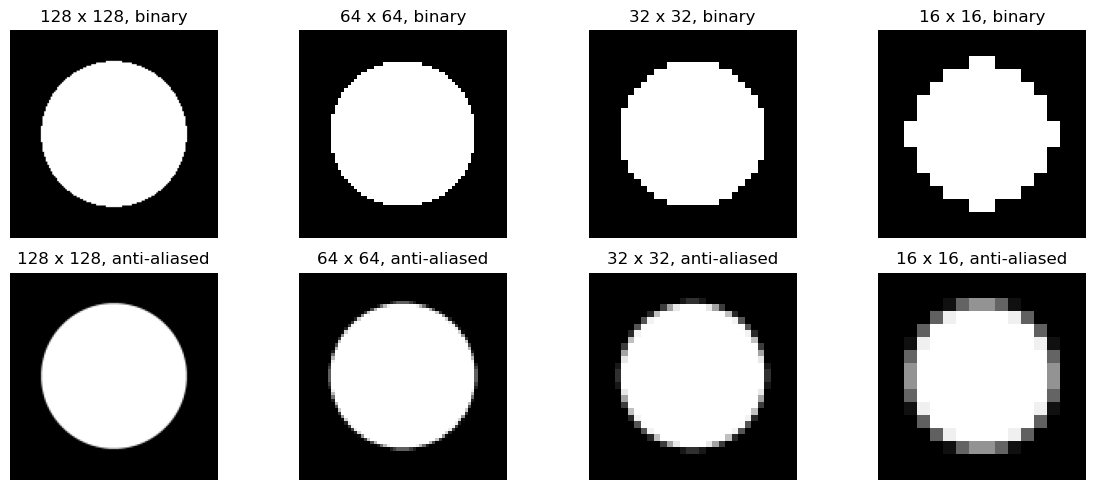

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize


def circle_image(n, radius=0.35, supersample=1):
    """
    Sample the indicator function of a disk on an n x n grid.

    supersample=1 gives hard binary pixels.
    supersample>1 approximates pixel-area averaging, i.e. anti-aliasing.
    """
    m = n * supersample

    x = (np.arange(m) + 0.5) / m
    y = (np.arange(m) + 0.5) / m
    X, Y = np.meshgrid(x, y)

    disk = ((X - 0.5)**2 + (Y - 0.5)**2 <= radius**2).astype(float)

    if supersample == 1:
        return disk

    # average over supersample x supersample blocks
    return disk.reshape(n, supersample, n, supersample).mean(axis=(1, 3))


resolutions = [128, 64, 32, 16]

fig, axes = plt.subplots(2, len(resolutions), figsize=(12, 5))

for j, n in enumerate(resolutions):
    img_binary = circle_image(n, supersample=1)
    img_aa = circle_image(n, supersample=8)

    axes[0, j].imshow(img_binary, cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"{n} x {n}, binary")
    axes[0, j].axis("off")

    axes[1, j].imshow(img_aa, cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title(f"{n} x {n}, anti-aliased")
    axes[1, j].axis("off")

plt.tight_layout()
plt.savefig('circles.png',dpi=300)

![](./circles.png)

## Types of noise

* We can think of noise as any feature in the image that diminishes its scientific usefulness
* This could include measurement noise, distortions, pre-processing artifacts, quantization, ...
* We will focus on noise that can be modelled stochastically, as perturbation of underlying "clean" image.

**Additive Gaussian noise:**

$$f_i\sim N (\overline{f}_i,\sigma^2)$$

**Poisson noise:**

$$f\sim P(\overline{f}_i)$$

**Salt-and-Pepper:**

$$f_i = \begin{cases} 0 & \text{with probability } p/2 \\ 1 & \text{with probability } p/2\\ \overline{f}_i & \text{with probability } 1-p \end{cases}$$

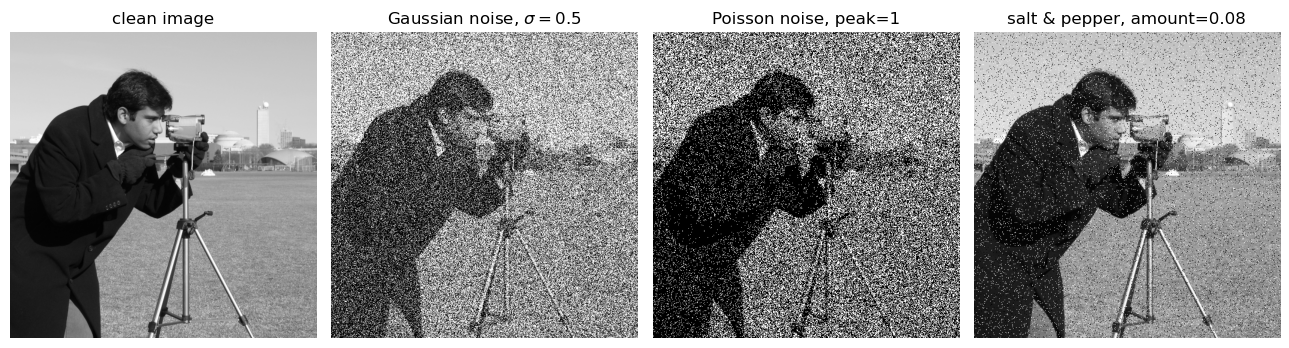

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.util import random_noise


# Clean image in [0, 1]
u = img_as_float(data.camera())

rng = np.random.default_rng(42)

# 1. Additive Gaussian noise
sigma = 0.50
u_gauss = u + sigma * rng.standard_normal(u.shape)
u_gauss = np.clip(u_gauss, 0, 1)

# 2. Poisson noise
# Interpret u as intensity controlling photon counts.
peak_counts = 1
counts = rng.poisson(peak_counts * u)
u_poisson = counts / peak_counts
u_poisson = np.clip(u_poisson, 0, 1)

# 3. Salt-and-pepper noise
amount = 0.08
u_sp = random_noise(u, mode="s&p", amount=amount, rng=42)


fig, axes = plt.subplots(1, 4, figsize=(13, 4))

images = [u, u_gauss, u_poisson, u_sp]
titles = [
    "clean image",
    f"Gaussian noise, $\\sigma={sigma}$",
    f"Poisson noise, peak={peak_counts}",
    f"salt & pepper, amount={amount}",
]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig('noisy-images.png',dpi=300)

![](./noisy-images.png)

## How do we compare images?

* We need a way to judge the quality of an image. Which metric is suitable is highly application (and community) dependent
* We discern methods with and without a reference.
* Without a reference: resolution, contrast, ...
* With a reference: SNR, MSE, SSIM, ...

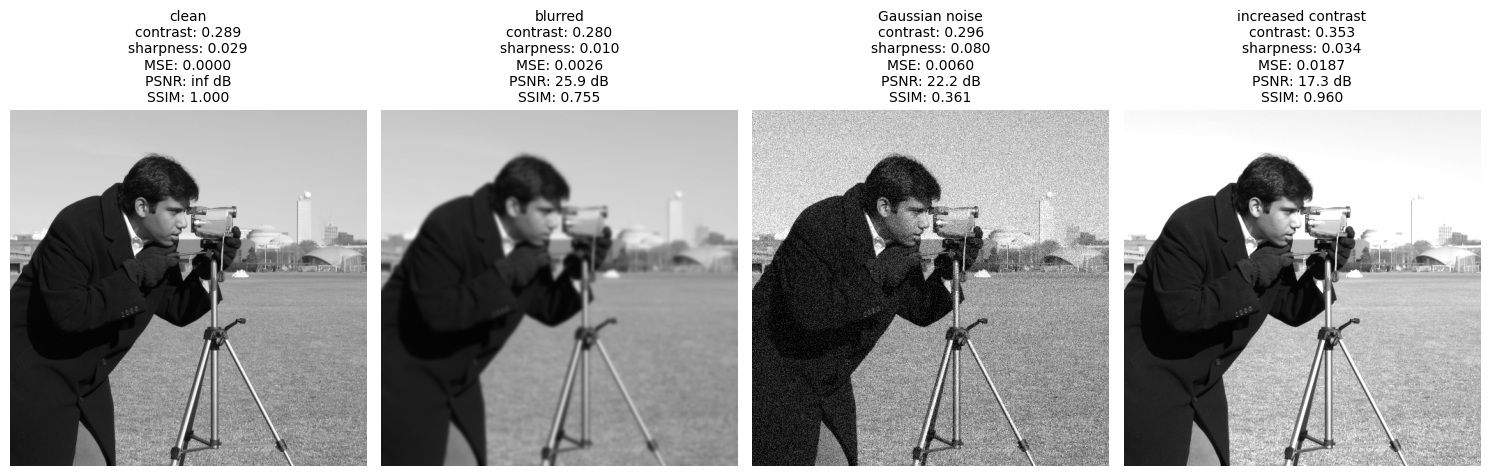

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))

for ax, img, title in zip(axes, images, titles):
    contrast = contrast_std(img)
    sharpness = sharpness_gradient(img)

    mse = mean_squared_error(u, img)
    psnr = peak_signal_noise_ratio(u, img, data_range=1)
    ssim = structural_similarity(u, img, data_range=1)

    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

    ax.set_title(
        f"{title}\n"
        f"contrast: {contrast:.3f}\n"
        f"sharpness: {sharpness:.3f}\n"
        f"MSE: {mse:.4f}\n"
        f"PSNR: {psnr:.1f} dB\n"
        f"SSIM: {ssim:.3f}",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig('image-metrics.png',dpi=300)

![](./image-metrics.png)

# Getting rid of noise

> *Getting rid of noise is easy, it's keeping the useful bits that is hard.*
>
> \- This lecture

# Bias and variance

Suppose we have a noisy image $F^\delta$ and a method to denoise the image:
$$\widetilde{F} = \mathcal{R}(F^\delta),$$
we want to study how well it approximates an underlying clean image $F$.

It is often usefull to think of the error

## Filtering and smoothing

* Local smoothing
* Median filtering
* Frequency-domain filtering

In [ ]:
# examples

examples

## Transform-domain tresholding

* DCT
* Wavelets
* SVD

In [ ]:
# examples

examles

## Variational denoising

Explicitly model the trade-off between bias and variance, and minimize it:
$$\min_{F} ...$$
The trick is to find the "right" value for $\lambda$.

Many of the approaches mentioned earlier can be modelled in this way. We focus here on Total Variation denoising

In [1]:
# TV example

TV example

## Beyond

* Patches
* Dictionary learning

In [2]:
# example with patches

example with patches / dictionary learning